Most dissimilar bands (Euclidean): (0, 11)
Most dissimilar bands (Correlation): (0, 7)


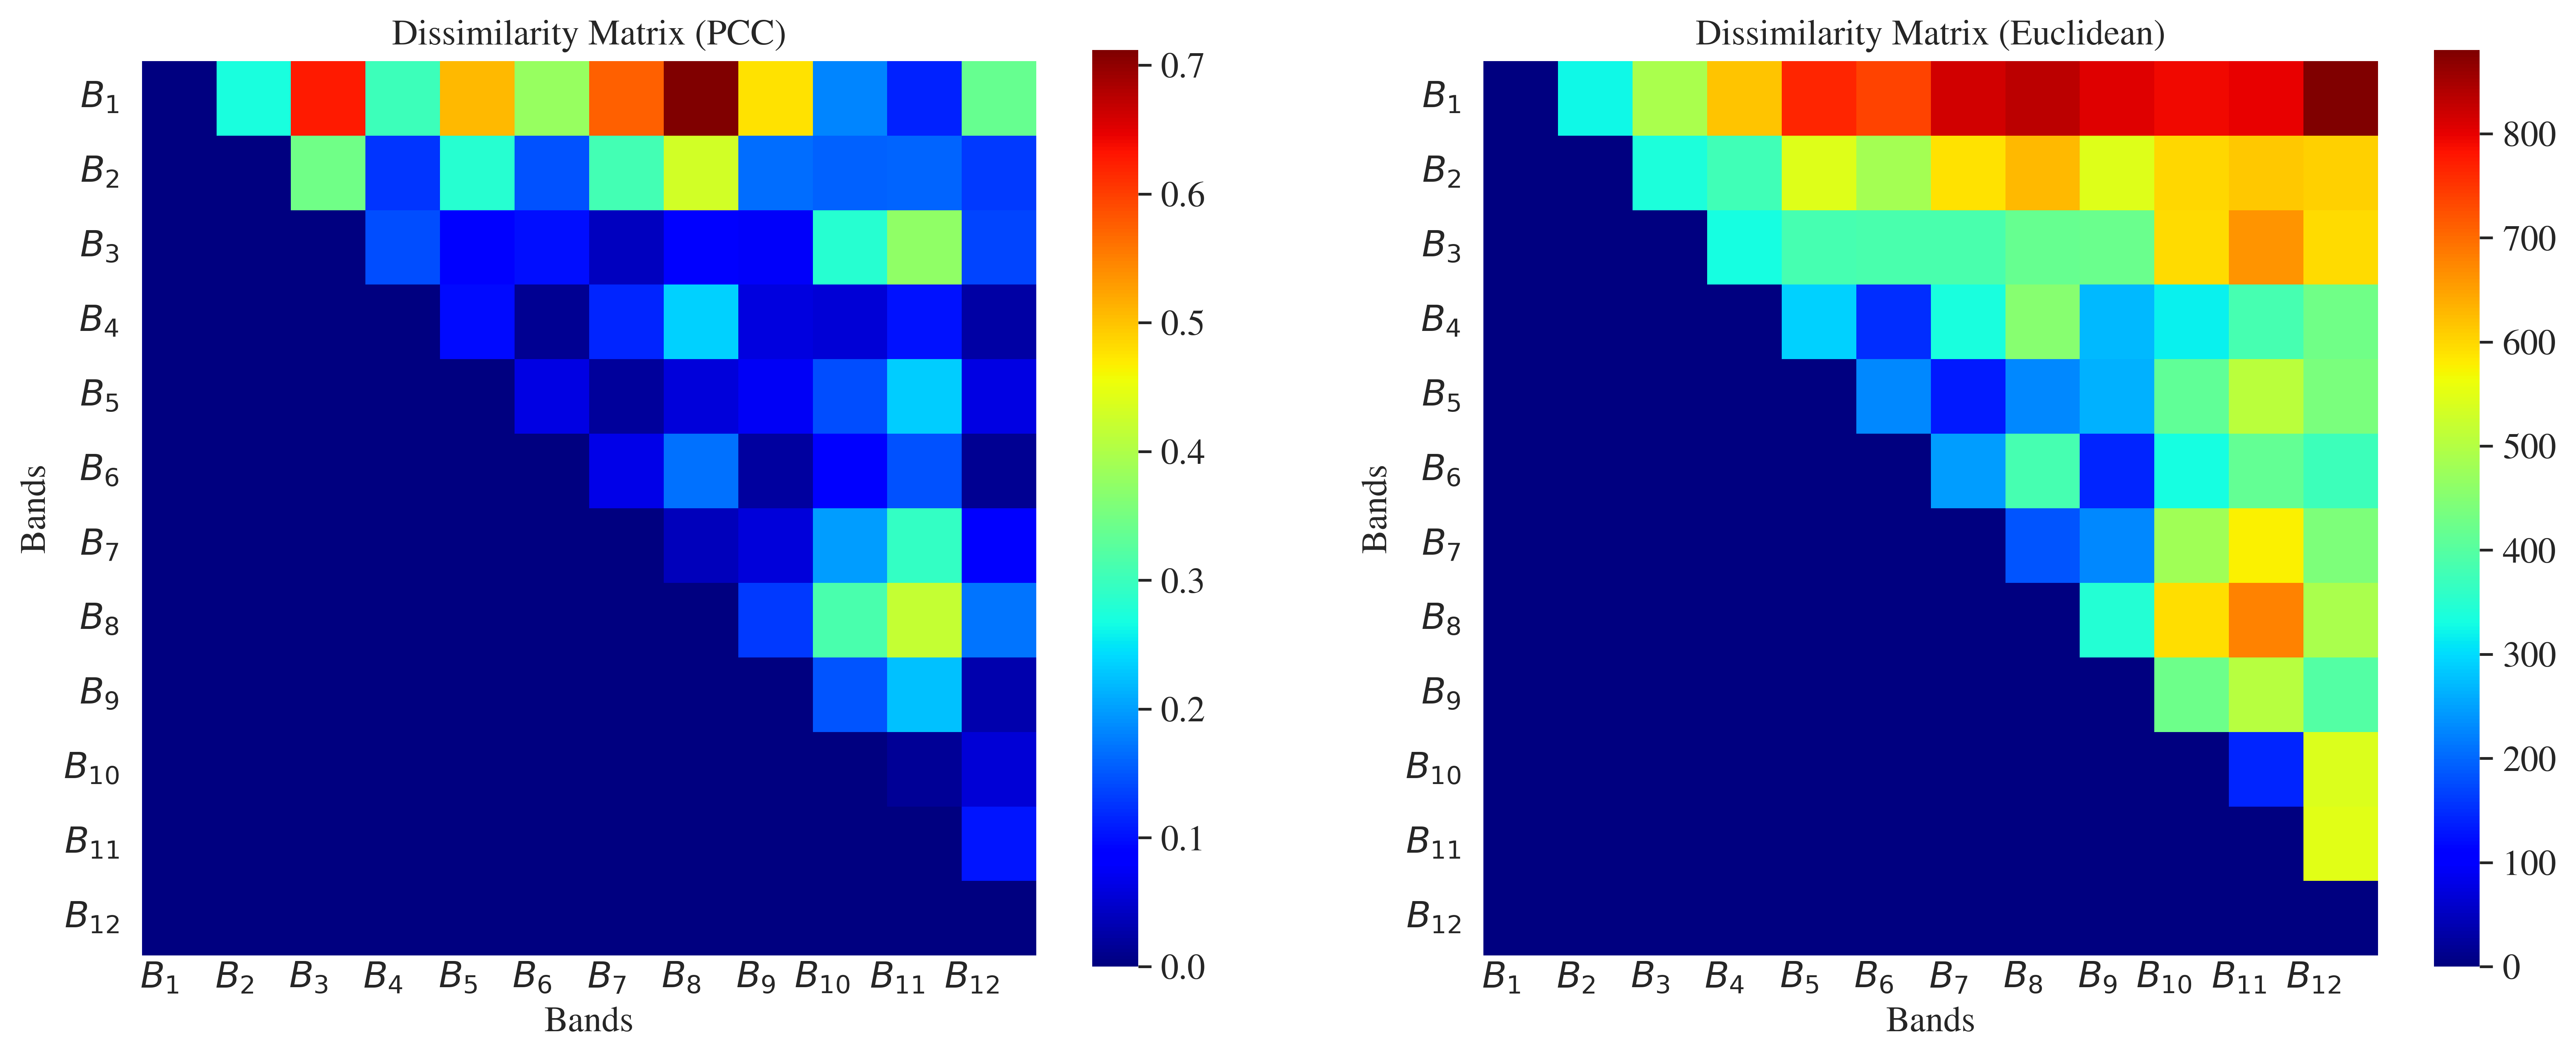

In [11]:
import numpy as np
from scipy.spatial.distance import euclidean
from scipy.stats import pearsonr
import seaborn as sns
from utils import list_files, set_style

set_style()

import matplotlib.pyplot as plt


band1_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B1')
band2_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B2')
band3_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B3')
band4_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B4')
band5_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B5')
band6_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B6')
band7_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B7')
band8_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B8')
band9_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B9')
band10_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B10')
band11_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B11')
band12_files = list_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B12')


band1, band2, band3, band4, band5, band6 = band1_files[0], band2_files[0], band3_files[0], band4_files[0], band5_files[0], band6_files[0]
band7, band8, band9, band10, band11, band12 = band7_files[0], band8_files[0], band9_files[0], band10_files[0], band11_files[0], band12_files[0]


bands = [band1, band2, band3, band4, band5, band6, band7, band8, band9, band10, band11, band12]

# Flatten each band into a 1D array
flattened_bands = [np.load(band).flatten() for band in bands]

# Calculate Euclidean distance and correlation for each pair of bands
num_bands = len(bands)
dissimilarity_matrix_euclidean = np.zeros((num_bands, num_bands))
dissimilarity_matrix_correlation = np.zeros((num_bands, num_bands))

for i in range(num_bands):
    for j in range(i+1, num_bands):
        dist = euclidean(flattened_bands[i], flattened_bands[j])
        corr, _ = pearsonr(flattened_bands[i], flattened_bands[j])
        
        dissimilarity_matrix_euclidean[i, j] = dist
        dissimilarity_matrix_correlation[i, j] = 1 - corr  # Dissimilarity

# The most dissimilar bands can be found by identifying the pairs with maximum values
most_dissimilar_bands_euclidean = np.unravel_index(np.argmax(dissimilarity_matrix_euclidean), dissimilarity_matrix_euclidean.shape)
most_dissimilar_bands_correlation = np.unravel_index(np.argmax(dissimilarity_matrix_correlation), dissimilarity_matrix_correlation.shape)

print("Most dissimilar bands (Euclidean):", most_dissimilar_bands_euclidean)
print("Most dissimilar bands (Correlation):", most_dissimilar_bands_correlation)


# Create a heatmap using seaborn
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(dissimilarity_matrix_correlation, annot=False, fmt=".1f", cmap='jet', square=True)
plt.title('Dissimilarity Matrix (PCC)')
plt.xlabel('Bands')
plt.ylabel('Bands')
# move the ticks down and to the right
plt.xticks([x-0.5 for x in range(1,len(bands)+1)], [f"$B_{{{i+1}}}$" for i in range(len(bands))], rotation=0, ha='right', va='center')
plt.yticks([x-0.5 for x in range(1,len(bands)+1)], [f"$B_{{{i+1}}}$" for i in range(len(bands))], rotation=0, ha='right', va='center')

plt.subplot(1, 2, 2)
sns.heatmap(dissimilarity_matrix_euclidean, annot=False, fmt=".1f", cmap='jet', square=True)
plt.title('Dissimilarity Matrix (Euclidean)')
plt.xlabel('Bands')
plt.ylabel('Bands')
# move the ticks down and to the right
plt.xticks([x-0.5 for x in range(1,len(bands)+1)], [f"$B_{{{i+1}}}$" for i in range(len(bands))], rotation=0, ha='right', va='center')
plt.yticks([x-0.5 for x in range(1,len(bands)+1)], [f"$B_{{{i+1}}}$" for i in range(len(bands))], rotation=0, ha='right', va='center')
plt.show()
